Instrucciones:

- Configura el entorno:
Usa gymnasium.make("CartPole-v1").

- Representación de la política:

Usa una red neuronal simple (ej. torch.nn.Sequential) que reciba el estado y devuelva probabilidades de acciones (0: izquierda, 1: derecha).

- Inicializa los parámetros de la política de forma aleatoria.

Implementa la técnica CEM:
En cada iteración:

- Genera un conjunto de episodios (N=50).

- Evalúa las recompensas totales.

- Selecciona el percentil top (ej. 70%) de episodios con mayor recompensa.

Ajusta los parámetros de la política usando los datos de los mejores episodios.

Criterio de convergencia:

- Termina el entrenamiento cuando el promedio de recompensas de los mejores episodios supere un umbral (ej. 450 puntos en CartPole).

Entrega esperada:

- Código en Python que entrene al agente.

- Gráfica de la recompensa promedio por iteración.

Abajo está el código base para completar los espacios

/var/folders/sl/_0vv98412kq54qbqdd087ztw0000gn/T/ipykernel_9530/2719330101.py:68: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:281.)
  elite_states_t = torch.tensor(elite_states, dtype=torch.float32)


Iter 0: mean reward = 17.06, threshold = 19.00
Iter 1: mean reward = 18.84, threshold = 20.00
Iter 2: mean reward = 19.38, threshold = 20.00
Iter 3: mean reward = 18.68, threshold = 19.30
Iter 4: mean reward = 19.20, threshold = 22.30
Iter 5: mean reward = 18.60, threshold = 22.30
Iter 6: mean reward = 16.96, threshold = 18.60
Iter 7: mean reward = 19.30, threshold = 22.30
Iter 8: mean reward = 15.68, threshold = 18.00
Iter 9: mean reward = 14.86, threshold = 16.00
Iter 10: mean reward = 14.36, threshold = 16.00
Iter 11: mean reward = 14.36, threshold = 16.00
Iter 12: mean reward = 12.78, threshold = 13.00
Iter 13: mean reward = 12.48, threshold = 13.00
Iter 14: mean reward = 11.82, threshold = 13.00
Iter 15: mean reward = 10.98, threshold = 12.00
Iter 16: mean reward = 11.06, threshold = 12.00
Iter 17: mean reward = 10.48, threshold = 11.00
Iter 18: mean reward = 10.40, threshold = 11.00
Iter 19: mean reward = 10.28, threshold = 10.30
Iter 20: mean reward = 9.78, threshold = 10.00
Ite

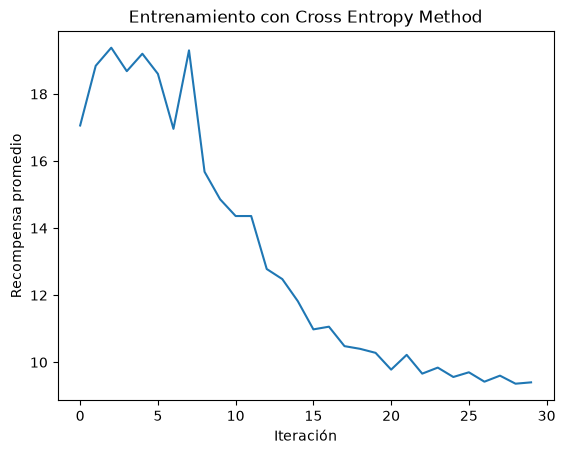

In [ ]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Crear el entorno
env = gym.make("CartPole-v1")

# 2. Definir política (MLP simple)
# El obejtivo es enrenar una red neuronal que tome el estado del entorno y devuelva una distribución de probabilidad sobre las acciones posibles.
# Que aprenda la politica que indica la probabilidad de tomar cada acción dado un estado.
class Policy(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 32),
            nn.ReLU(),
            nn.Linear(32, action_dim),
            nn.Softmax(dim=-1)
        )
    def forward(self, x):
        return self.net(x)

# Inicializar política y optimizador
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
policy = Policy(state_dim, action_dim)
optimizer = optim.Adam(policy.parameters(), lr=0.01)

# -------- FUNCIÓN PARA GENERAR EPISODIOS ----------
# Un episodio es una secuencia de estados, acciones y recompensas que termina cuando el entorno indica que el episodio ha terminado (done).
def generate_episode(policy, env): 
    states, actions, rewards = [], [], []
    obs, _ = env.reset()
    done = False
    while not done:
        state_t = torch.tensor(obs, dtype=torch.float32)
        probs = policy(state_t)   # TODO: pasar el estado
        action = torch.distributions.Categorical(probs).sample().item()  # TODO: usar las probabilidades
        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        states.append(obs)
        actions.append(action)   # TODO: guardar la acción
        rewards.append(reward)   # TODO: guardar la recompensa
        obs = next_obs
    return states, actions, sum(rewards)

# --------- CROSS ENTROPY METHOD -----------
N = 50          # episodios por iteración
percentile = 70 # selección de élite
n_iterations = 30
reward_history = []

for iteration in range(n_iterations):
    batch = [generate_episode(policy, env) for _ in range(N)]
    rewards = [episode[2] for episode in batch]
    reward_threshold = np.percentile(rewards, percentile)  # TODO: usar el percentil

    # seleccionar elite
    elite_states = []
    elite_actions = []
    for states, actions, total_r in batch:
        if total_r >= reward_threshold:   # TODO: aplicar el umbral
            elite_states.extend(states)
            elite_actions.extend(actions)

    # convertir a tensores
    elite_states_t = torch.tensor(elite_states, dtype=torch.float32)
    elite_actions_t = torch.tensor(elite_actions, dtype=torch.int64)

    # actualizar política
    optimizer.zero_grad()
    logits = policy(elite_states_t)  # TODO: pasar los estados elite
    loss = nn.CrossEntropyLoss()(logits, elite_actions_t)  # TODO: usar acciones elite
    loss.backward()
    optimizer.step()

    mean_reward = np.mean(rewards)
    reward_history.append(mean_reward)
    print(f"Iter {iteration}: mean reward = {mean_reward:.2f}, threshold = {reward_threshold:.2f}") #Este metodo de Cross Entropy Method 
    # es un metodo de optimizacion que busca encontrar la mejor politica para maximizar 
    # la recompensa en un entorno de aprendizaje por refuerzo. 
    # En cada iteracion, se generan N episodios, se seleccionan los episodios con 
    # recompensas superiores a un percentil dado, y se actualiza la politica usando esos episodios.

# --------- GRAFICAR -----------
plt.plot(reward_history)
plt.xlabel("Iteración")
plt.ylabel("Recompensa promedio")
plt.title("Entrenamiento con Cross Entropy Method")
plt.show()
